In [28]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert
import pandas as pd
import scipy as sp
import os

In [29]:
os.chdir(r'C:\Users\sydne\git\erth370\erth370-w2026-sydpas')
print(f'Directory: {os.getcwd()}')  # shows current working directory
os.makedirs(r"figures/line01/final_jacobian", exist_ok=True)

filename = r'data\line01\og_fromtomsnotes_mytopo\project_5\Dipole-Dipole_1-2018-06-11-161704.dat'
data = ert.load(filename)
print(data)

xs = np.array([s.x() for s in data.sensors()])  # an array of all elec x-positions along line
data_min = xs.min(); data_max = xs.max()
print(data_min, data_max)

20/04/26 - 13:47:07 - pyGIMLi - INFO - could not read unified data format for ERT ... try res2dinv


Directory: C:\Users\sydne\git\erth370\erth370-w2026-sydpas
Data: Sensors: 81 data: 1469, nonzero entries: ['a', 'b', 'm', 'n', 'r', 'valid']
0.0 400.0


In [30]:
topo = []

topo_file = r'data\line01\og_fromtomsnotes_mytopo\400_line01_mytopo.txt'

with open(topo_file) as f: 
    next(f)  # skip header line
    for line in f:
        line = line.strip()
        parts = line.split()  # split using whitespace
        if len(parts) == 2:  # if data has 2 columns it is topo data so add to the list
            topo.append([float(parts[0]), float(parts[1])])

topo = np.array(topo)  # convert to numpy array

topo = topo[np.argsort(topo[:,0])]

x_elec = pg.x(data)  # get x pos of all electrodes
z_elec = np.interp(x_elec, topo[:,0], topo[:,1])  # interpolate topo at each electrode

x_elec = np.array(pg.x(data))  # convert RVector to numpy

# now we ensure topo covers all electrodes at both ends
if topo[0,0] > x_elec.min():  # if topo is to the right of (after) electrode
    topo = np.vstack(([x_elec.min(), topo[0,1]], topo))
if topo[-1,0] < x_elec.max():  # if topo is to the left of (before) electrode
    topo = np.vstack((topo, [x_elec.max(), topo[-1,1]]))

# second interp of topo at electrode positions
z_interp = np.interp(x_elec, topo[:,0], topo[:,1])

# set electrode positions in data
data.setSensorPositions(pg.PosVector(np.c_[x_elec, z_interp]))  # combine into 2D array, convert to gimli pos vector, and update elec pos in ERT dataset

# ensure arrays
x_elec = np.array(pg.x(data))
z_interp = np.array(z_interp)

plt.figure(figsize=(10,4))
plt.plot(x_elec, z_interp, 'r*')
plt.xlabel('Electrode Location [m]')
plt.ylabel('Elevation [m]')
plt.title('Topography')
# plt.show()
plt.close()

In [31]:
def build_electrode_scheme(type, sensors_x, sensors_y):

    elecs = np.c_[sensors_x, sensors_y]   # combine x and z

    # remove the two bad electrodes
    elecs = elecs[2:]

    scheme = ert.createData(elecs=elecs, schemeName=type)

    return scheme

In [ ]:
nelecs = 81  # from data file
pos = np.zeros((nelecs, 2))
pos[:, 0] = np.linspace(5, 25, nelecs)

#comment one or the other out
scheme = build_electrode_scheme('gr', x_elec, z_interp)
scheme["k"] = ert.createGeometricFactors(scheme)

# scheme = build_electrode_scheme('dd', x_elec, z_interp)
# scheme["k"] = ert.createGeometricFactors(scheme)

20/04/26 - 13:47:15 - pyGIMLi - INFO - Save RVector binary
20/04/26 - 13:47:15 - pyGIMLi - INFO - Cache stored: C:\Users\sydne\AppData\Roaming\pygimli\Cache\13026809788237523630
20/04/26 - 13:47:15 - pyGIMLi - INFO - Save RVector binary
20/04/26 - 13:47:15 - pyGIMLi - INFO - Cache stored: C:\Users\sydne\AppData\Roaming\pygimli\Cache\11847659943446239422


> from claude

**world_topo**: Creates the outer boundary of the mesh as a closed polygon
- It's built by taking your topography and closing it off at the bottom
- Shape is essentially: left edge → topography surface → right edge → flat bottom

**topo_line**: Creates just the surface topography line as an open polygon (not closed)
- marker=-1 flags it as a boundary constraint, forcing the mesher to respect the surface shape
- This is what makes the mesh surface follow your actual topography rather than being flat

**geom**: Merges both into a single PLC (Piecewise Linear Complex)
- This is the final geometry handed to createMesh

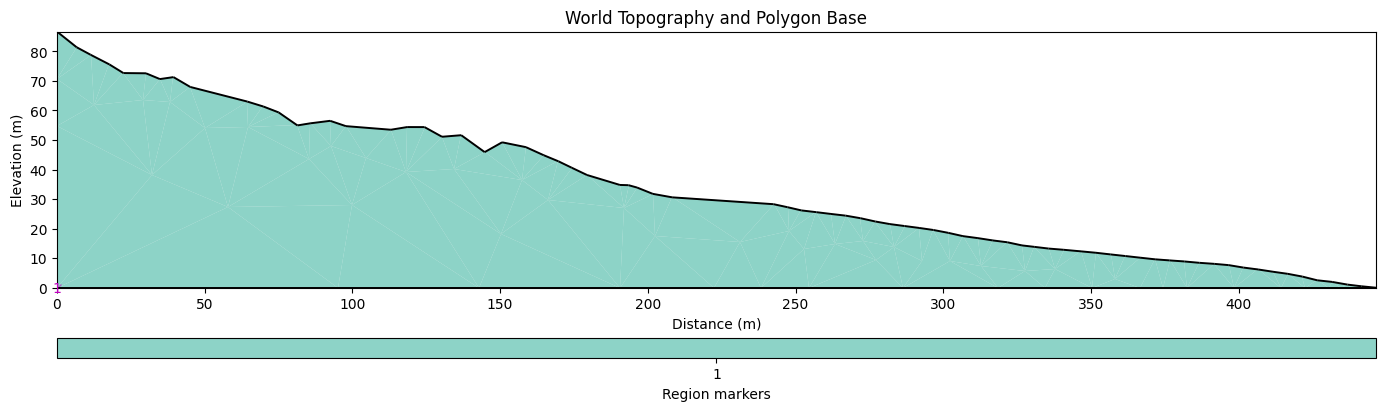

In [33]:
world_bottom = topo[:,1].min()

world_topo = mt.createPolygon(
    [[topo[0,0], world_bottom]] + topo.tolist() + [[topo[-1,0], world_bottom]],
    isClosed=True,marker=1)

top_mean = topo[:,1].mean()

topo_line = mt.createPolygon(
    topo,
    isClosed=False,
    marker=-1
)

# topo nodes are created automatically here
geom = mt.mergePLC([world_topo, topo_line])

fig, ax = plt.subplots(figsize=(14,8))

pg.show(geom, ax=ax)

ax.set_xlabel('Distance (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title('World Topography and Polygon Base')

fig.savefig(r"figures/line01/final_jacobian/1world_topo.png", dpi=400, bbox_inches='tight')

> from claude

**mt.createMesh()**: with a PLC geometry uses Triangle (a Delaunay triangulator)
- https://www.pygimli.org/pygimliapi/_generated/pygimli.meshtools.html 
    - https://www.pygimli.org/_modules/pygimli/meshtools/mesh.html#createMesh 
    - https://www.pygimli.org/glossary.html#term-Triangle 
- https://www.cs.cmu.edu/~quake/triangle.html
    - https://www.cs.cmu.edu/~quake/triangle.defs.html

Mesh geometry → from topography points

Electrode positions → constrain where current is injected/measured

Starting model → uniform resistivity (1 Ohm·m) assigned to all mesh cells.

Jacobian then tells you how sensitive your measurements are to each of those mesh cells.

In [34]:
area_val = 1
qualll = 32

mesh = mt.createMesh(geom, quality=qualll, area=area_val, smooth=[1,10])

In [35]:
nodes = np.array([[mesh.node(i).x(), mesh.node(i).y()] for i in range(mesh.nodeCount())])
cells = np.array([[mesh.cell(i).node(j).id() for j in range(mesh.cell(i).nodeCount())] for i in range(mesh.cellCount())])

print(f'Number of nodes: {mesh.nodeCount()}')
print(f'Number of cells: {mesh.cellCount()}')

df = pd.DataFrame(cells[:500], columns=['node_0', 'node_1', 'node_2'])
for col in ['node_0', 'node_1', 'node_2']:
    df[f'{col}_x'] = df[col].apply(lambda i: nodes[i][0])
    df[f'{col}_y'] = df[col].apply(lambda i: nodes[i][1])
# print(df.to_string())

rows = []
for _, r in df.iterrows():
    rows.append((r.node_0_x, r.node_0_y))
    rows.append((r.node_1_x, r.node_1_y))
    rows.append((r.node_2_x, r.node_2_y))
    rows.append((r.node_0_x, r.node_0_y))  # close the triangle
    rows.append((None, None))               # blank row = break between triangles

plot_df = pd.DataFrame(rows, columns=['x', 'y'])
# print(plot_df.to_string())

Number of nodes: 12983
Number of cells: 25172


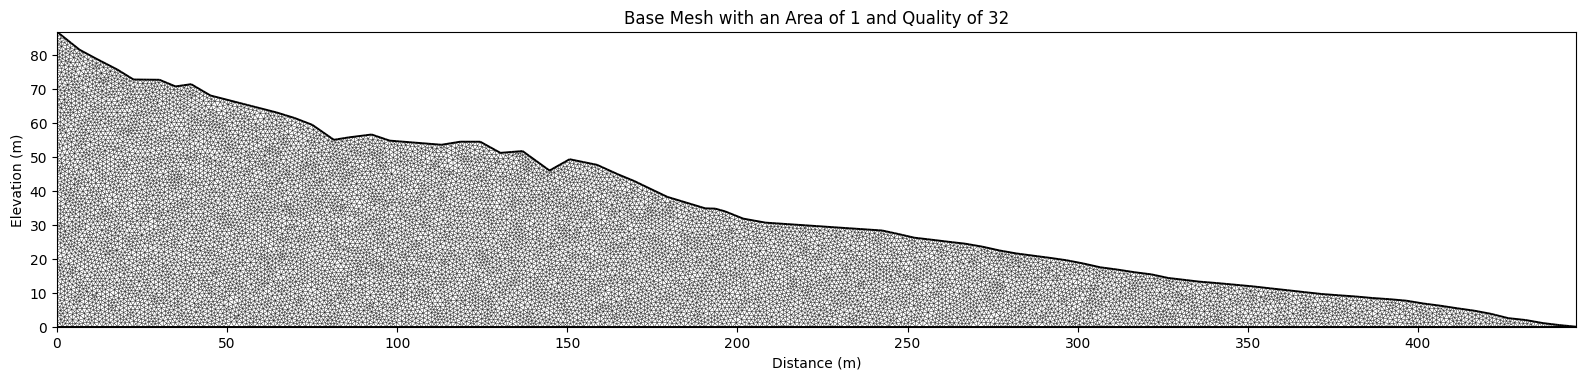

In [36]:
fig, ax = plt.subplots(figsize=(16,4))
pg.show(mesh, ax=ax, showMesh=True)

ax.set_xlabel('Distance (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title(f'Base Mesh with an Area of {area_val} and Quality of {qualll}')

fig.savefig(r"figures/line01/final_jacobian/2mesh.png", dpi=400, bbox_inches='tight')

> for trouble shooting...

**this is common error**:

mesh cell count: 20450

mesh node count: 10479

Cell for sensor RVector3: (5.0, 86.7172, 0.0): None

sensor outside mesh: RVector3: (5.0, 86.7172, 0.0)

Cell for sensor RVector3: (5.25, 82.72896607105152, 0.0): None

sensor outside mesh: RVector3: (5.25, 82.72896607105152, 0.0)

Cell for sensor RVector3: (5.5, 79.60510881330036, 0.0): <pgcore._pygimli_.Triangle object at 0x00000182585BBDF0> ID: 16781, Marker: 1, Size: 1.8418247009920454 8209 RVector3: (4.679328259648554, 80.14537369749408, 0.0) 8588 RVector3: (5.268856563298982, 77.93652249843612, 0.0) 7790 RVector3: (6.623138830301008, 79.1107517735486, 0.0)

...and we DON'T want it to say *sensor outside mesh*.

In [37]:
print(f'mesh cell count: {mesh.cellCount()}')
print(f'mesh node count: {mesh.nodeCount()}')

for n in mesh.nodes():
    if len(n.cellSet()) == 0:
        print("isolated node:", n.id(), n.pos())

for p in scheme.sensorPositions():
    cell = mesh.findCell(p)
    print(f'Cell for sensor {p}: {cell}')
    if mesh.findCell(p) is None:
        print("sensor outside mesh:", p)

mesh cell count: 25172
mesh node count: 12983
Cell for sensor RVector3: (10.0, 79.60510881330036, 0.0): <pgcore._pygimli_.Triangle object at 0x000001D2FE3D7ED0>	ID: 24453, Marker: 1, Size: 0.9169934678243565
	12851 RVector3: (10.223008429, 79.485225, 0.0)
	12594 RVector3: (9.040801858, 80.12075, 0.0)
	12724 RVector3: (9.115806605874297, 78.52910402695328, 0.0)

Cell for sensor RVector3: (15.0, 76.99908541985687, 0.0): <pgcore._pygimli_.Triangle object at 0x000001D2FE3D66C0>	ID: 21765, Marker: 1, Size: 0.8050326828699227
	11198 RVector3: (14.581561115, 77.2145, 0.0)
	11610 RVector3: (14.909229074941337, 76.0320301923683, 0.0)
	11223 RVector3: (16.1697341725, 76.3969, 0.0)

Cell for sensor RVector3: (20.0, 74.19888043162373, 0.0): <pgcore._pygimli_.Triangle object at 0x000001D2FE3D5EE0>	ID: 21764, Marker: 1, Size: 0.8082507798548619
	11206 RVector3: (20.13226021, 74.11745, 0.0)
	11217 RVector3: (18.94508372, 74.848375, 0.0)
	11222 RVector3: (18.70874867519817, 73.63224717128269, 0.0)

Ce

Nodes: 29,409 — the points/vertices in the mesh (your topography points plus all the automatically generated interior points)
- Nodes (29,409) — these are the P1, P2, P3 corner points of each triangle where the Jacobian coordinates (x1, y1), (x2, y2), (x3, y3) are defined

Cells: 57,712 — the individual triangles that fill the domain (this is what gets assigned resistivity values)
- Cells (57,712) — these are the triangles described in your theory, each defined by 3 nodes arranged CCW with points P1, P2, P3. Each triangle has its own mesh quality Jacobian computed from those coordinates.

Boundaries: 43,836 — the edges shared between triangles, used to apply boundary conditions in the FEM solver
- Boundaries (43,836) — these are the edges between triangles, which in FEM are used to assemble the element matrices (Si, St in your createJacobian code)

In [38]:
fop = ert.ERTModelling()
fop.setData(scheme)
fop.setMesh(mesh)

model = np.ones(mesh.cellCount())
fop.verbose = True
#This runs one forward solve and computes J for that single model state
# No inversion, no iteration — just coverage
fop.createJacobian(model)

print(f'jacobian size: {len(fop.jacobian())} rows, {len(fop.jacobian()[0])} columns')
print(f'parameter mesh nodes ({mesh.nodeCount()}), cells ({mesh.cellCount()}), and boundaries ({mesh.boundaryCount()})')

20/04/26 - 13:47:46 - pyGIMLi - INFO - Found 1 regions.
20/04/26 - 13:47:46 - pyGIMLi - INFO - Creating forward mesh from region infos.
20/04/26 - 13:47:47 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
20/04/26 - 13:47:48 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 51137 Cells: 100688 Boundaries: 76308


jacobian size: 2926 rows, 25172 columns
parameter mesh nodes (12983), cells (25172), and boundaries (38154)


In [39]:
def getABMN(scheme, idx):
    """ Get coordinates of four-point cfg with id `idx` from DataContainerERT
    `scheme`."""
    coords = {}
    for elec in "abmn":
        elec_id = int(scheme(elec)[idx])
        elec_pos = scheme.sensorPosition(elec_id)
        coords[elec] = elec_pos.x(), elec_pos.y()
        # print(f"{elec}: x={elec_pos.x()}")

    return coords


def plotABMN(ax, scheme, idx):
    """ Visualize four-point configuration on given axes. """
    coords = getABMN(scheme, idx)
    for elec in coords:
        x, y = coords[elec]
        if elec in "ab":
            color = "red"
        else:
            color = "blue"
        ax.plot(x, y, marker=".", color=color, ms=10)
        ax.annotate(elec.upper(), xy=(x, y), ha="center", fontsize=10, bbox=dict(
            boxstyle="round", fc=(0.8, 0.8, 0.8), ec=color), xytext=(0, 20),
                    textcoords='offset points', arrowprops=dict(
                        arrowstyle="wedge, tail_width=.5", fc=color, ec=color,
                        patchA=None, alpha=0.75))
        ax.plot(coords["a"][0],)

def calc_res_mat(jacobian):
    temp_a = pg.utils.gmat2numpy(jacobian).transpose()
    A = np.matmul(temp_a.transpose(),temp_a)
    B = temp_a.transpose()
    resolution_matrix = sp.linalg.solve(A,B)
    return resolution_matrix

In [ ]:
measure = 100

nplots = len(range(0, len(fop.jacobian()), measure))

fig, ax = plt.subplots(
    nplots, 1,
    sharex=True,
    figsize=(16, 3*nplots)   # width , height per plot
)

for j, i in enumerate(range(0, len(fop.jacobian()), measure)):
    print(f'running measurement {i}...')

    sens = fop.jacobian()[i]

    plotABMN(ax[j], scheme, i)
    resolution_matrix = calc_res_mat(fop.jacobian())


    # normalize by cell size
    normsens = pg.utils.logDropTol(sens/mesh.cellSizes(), 8e-4)

    if i==0:
        norm_sum = np.abs(normsens)
        res_sum = resolution_matrix[i,:]
    else:  # cumulative
        norm_sum = norm_sum+np.abs(normsens)
        res_sum = res_sum+resolution_matrix[i,:]

    # normalize to max
    normsens = np.abs(normsens)
    normsens /= np.max(normsens)

    # from testing
    plotABMN(ax[0], scheme, i)
    pg.show(mesh,normsens, cMap="jet", orientation="vertical",
        label="Normalized Sensitivity", nLevs=3,ax=ax[0])

    # from combining
    # plotABMN(ax[j], scheme, i)
    # resolution_matrix = calc_res_mat(fop.jacobian())

    pg.show(mesh, normsens,
            cMap="jet", ax=ax[j], orientation="vertical", label="Normalized\nsensitivity", nLevs=3,
            cMin=-1, cMax=1)
    ax[j].set_title(f"Measurement {i}")
    
    plt.close()

plt.tight_layout()

running measurement 0...


C:\Users\sydne\AppData\Local\Temp\ipykernel_33256\200457072.py:35: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.751656609820612e-23.
  resolution_matrix = sp.linalg.solve(A,B)


running measurement 100...


c:\Users\sydne\anaconda3\envs\pg\Lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1600x9000 with 32 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)


running measurement 200...


...

running measurement 1200...


c:\Users\sydne\anaconda3\envs\pg\Lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1600x9000 with 43 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)


running measurement 1300...


c:\Users\sydne\anaconda3\envs\pg\Lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1600x9000 with 44 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)


running measurement 1400...


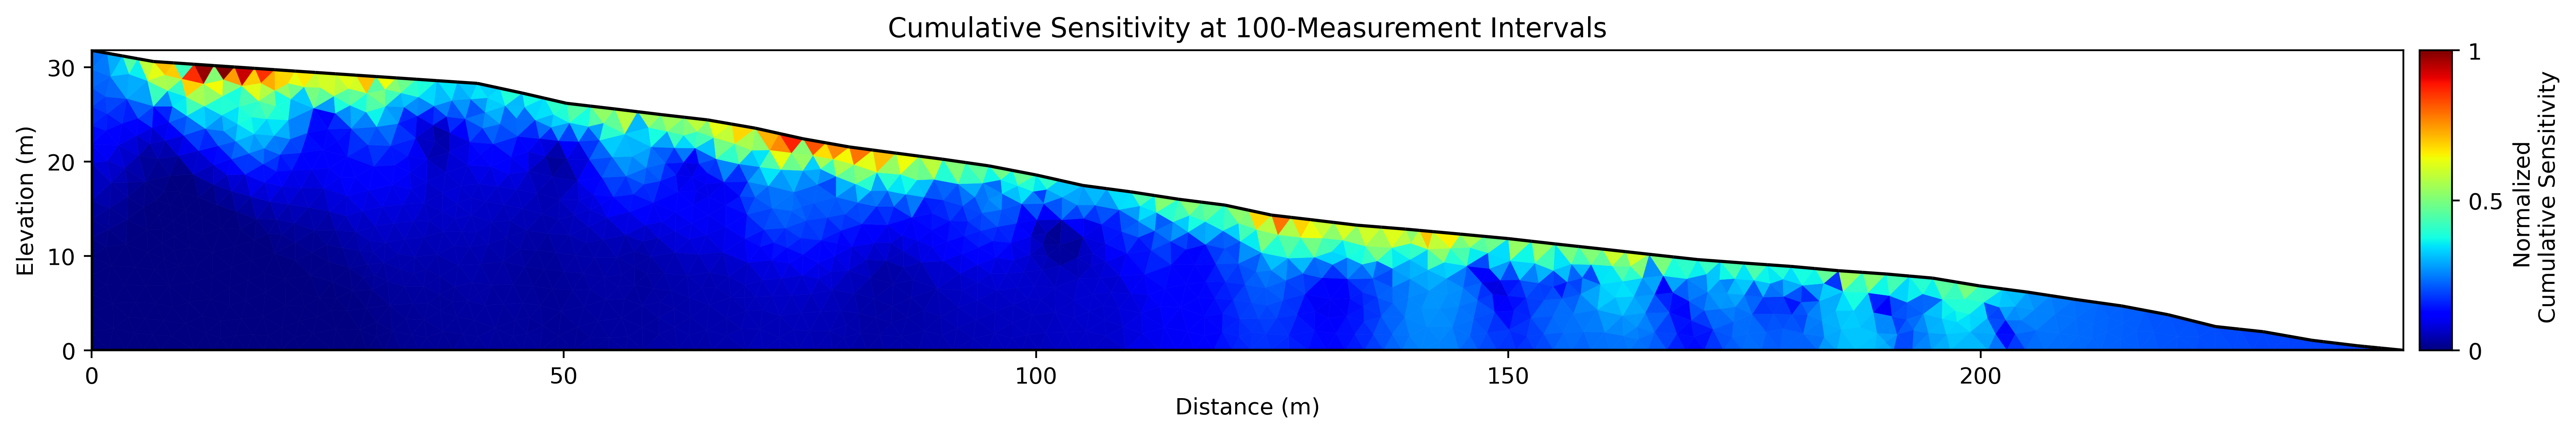

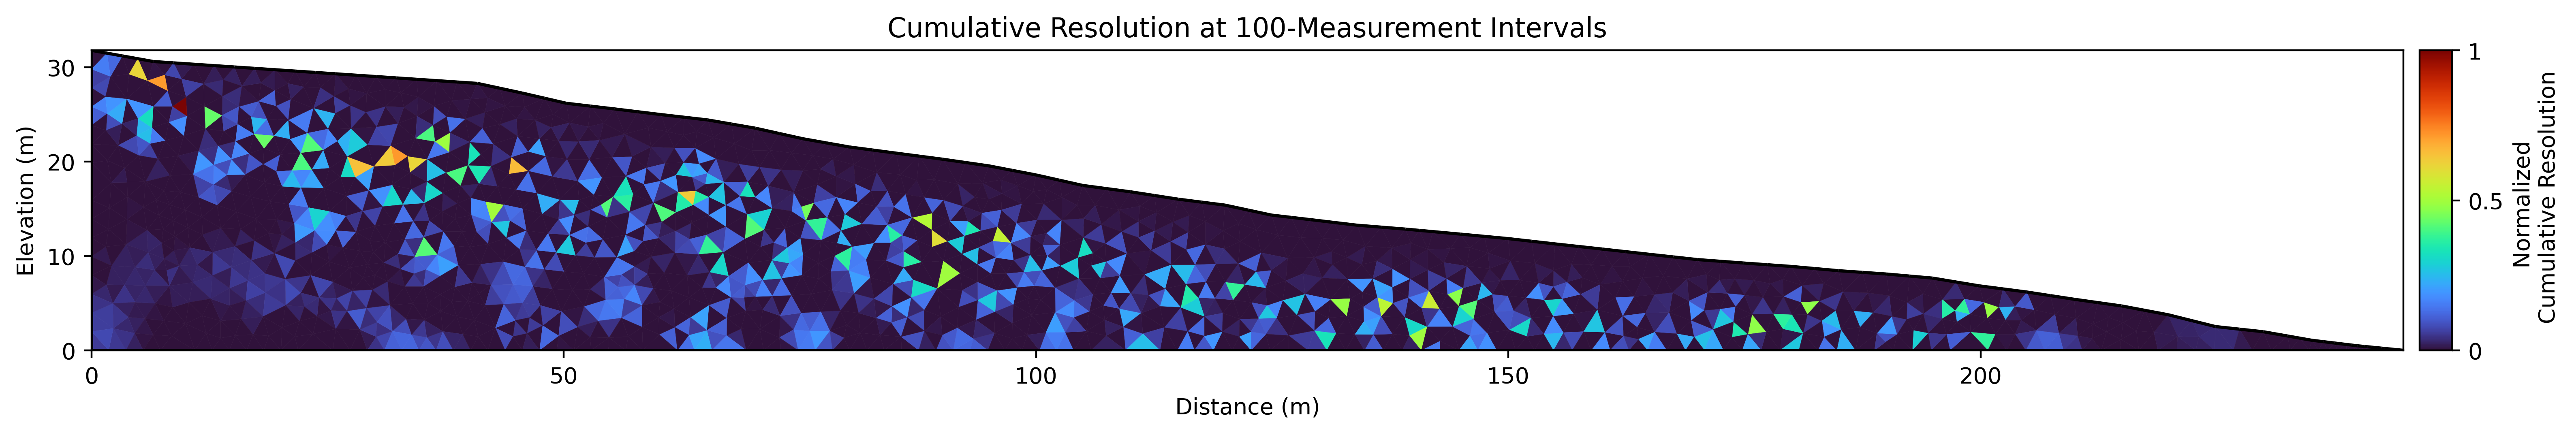

In [27]:
norm_sum /= np.max(norm_sum)
sens_sum = norm_sum

fig, ax = plt.subplots(figsize=(16, 8), dpi=400)

pg.show(mesh, sens_sum, cMap="jet", orientation="vertical",
        label="Normalized \n Cumulative Sensitivity", nLevs=3, cMin=0, cMax=1, ax=ax)

ax.set_xlabel('Distance (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title(f'Cumulative Sensitivity at {measure}-Measurement Intervals')

fig.savefig(r"figures/line01/final_jacobian/3cumsens_max1.png", dpi=400, bbox_inches='tight')

#####

res_sum /= np.max(res_sum)

fig, ax = plt.subplots(figsize=(16, 8), dpi=400)

pg.show(mesh, res_sum, cMap="turbo", orientation="vertical",
        label="Normalized \n Cumulative Resolution",nLevs=3,cMin=0,cMax=1, ax=ax)

ax.set_xlabel('Distance (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title(f'Cumulative Resolution at {measure}-Measurement Intervals')

fig.savefig(r"figures/line01/final_jacobian/4cumreso_max1.png", dpi=400, bbox_inches='tight')


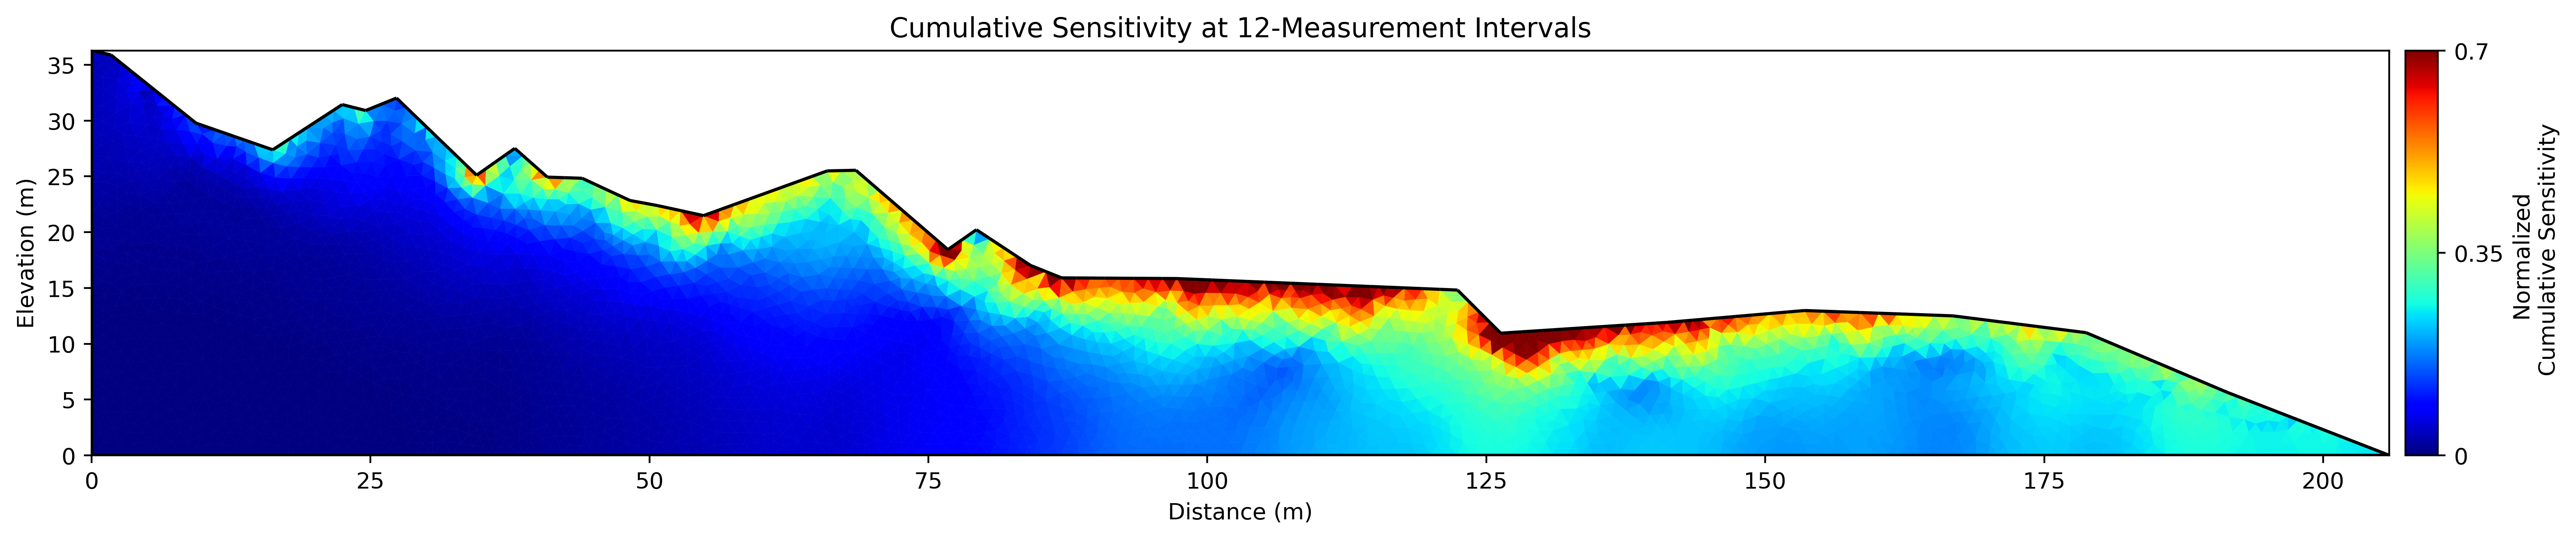

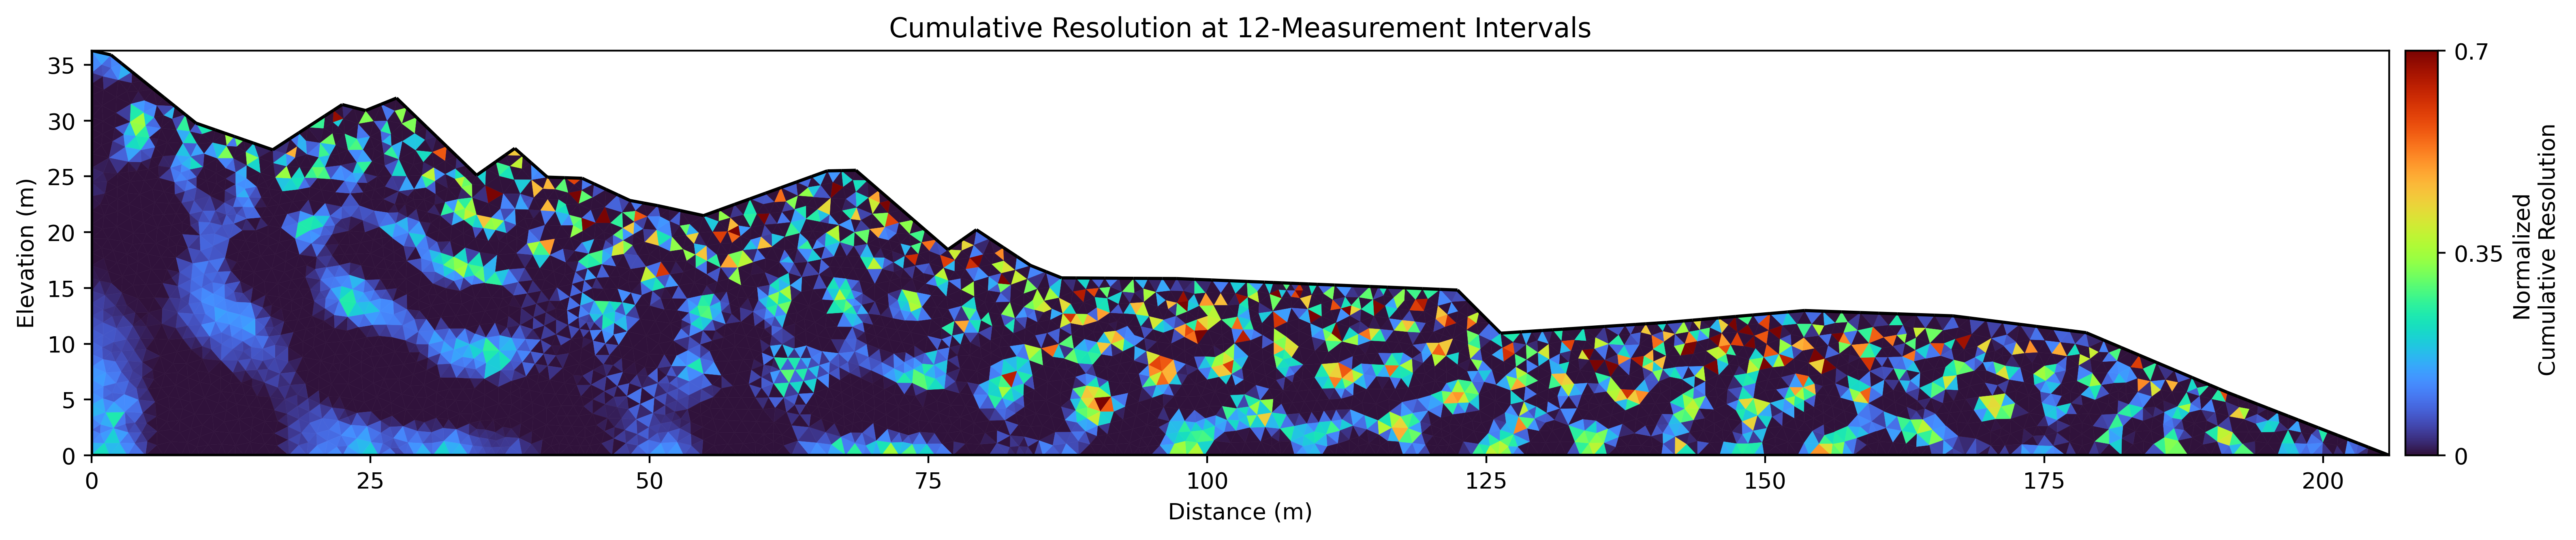

In [ ]:
norm_sum /= np.max(norm_sum)
sens_sum = norm_sum

fig, ax = plt.subplots(figsize=(16, 8), dpi=400)

pg.show(mesh, sens_sum, cMap="jet", orientation="vertical",
        label="Normalized \n Cumulative Sensitivity", nLevs=3, cMin=0, cMax=0.7, ax=ax)

ax.set_xlabel('Distance (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title(f'Cumulative Sensitivity at {measure}-Measurement Intervals')

fig.savefig(r"figures/line01/final_jacobian/3cumsens_max07.png", dpi=400, bbox_inches='tight')

#####

res_sum /= np.max(res_sum)

fig, ax = plt.subplots(figsize=(16, 8), dpi=400)

pg.show(mesh, res_sum, cMap="turbo", orientation="vertical",
        label="Normalized \n Cumulative Resolution",nLevs=3,cMin=0,cMax=0.7, ax=ax)

ax.set_xlabel('Distance (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title(f'Cumulative Resolution at {measure}-Measurement Intervals')

fig.savefig(r"figures/line01/final_jacobian/4cumreso_max07.png", dpi=400, bbox_inches='tight')